# 0823_kimjaehak_001_eda

> Siemens PCB AOI 데이터의 전체 구조와 품질을 파악하는 첫 EDA입니다. 실제 행이나 불필요한 고유값을 노출하지 않고 집계 결과만 확인합니다.

## 분석 배경

원 논문 *Data of automated optical inspection of surface-mounted technology electronic production* (Pfab et al., 2024)에 따르면 이 데이터는 AOI가 불량으로 의심해 수동 검사로 보낸 납땜 지점만 포함합니다. `class=0`은 false call(실제 정상), `class=1`은 true defect(실제 불량)입니다. 논문은 극심한 클래스 불균형, 시간에 따른 분포 변화 가능성, 작업자 판정에 의한 라벨 노이즈를 주요 한계로 제시합니다.

이 노트북은 다음 질문에 답합니다.

1. 파일과 스키마가 논문의 설명 및 `mapping.json`과 일치하는가?
2. 타깃과 검사유형의 분포는 어떠한가?
3. 결측, 무한값, 중복, 상수열 등 데이터 품질 문제는 무엇인가?
4. 검사유형별 유효 피처를 어떻게 구분해야 하는가?
5. 시간 및 그룹 구조를 고려할 때 후속 모델링은 어떻게 분할해야 하는가?

## 1. 설정과 라이브러리

저장소 루트와 노트북 디렉터리 어디에서 실행해도 원본 파일을 찾도록 경로를 결정합니다. 원본 파일은 읽기만 하며 수정하지 않습니다.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

EXPERIMENT_ID = "0823_kimjaehak_001_eda"
RANDOM_STATE = 42

candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (path for path in candidate_roots if (path / "data/raw/dataset.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("data/raw/dataset.csv를 찾을 수 없습니다. 저장소 루트에서 실행하세요.")

DATA_PATH = REPO_ROOT / "data/raw/dataset.csv"
MAPPING_PATH = REPO_ROOT / "data/raw/mapping.json"
PAPER_PATH = REPO_ROOT / "docs/1-s2.0-S2352340924000830-main.pdf"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("experiment:", EXPERIMENT_ID)
print("python:", platform.python_version())
print("pandas:", pd.__version__)
print("data file exists:", DATA_PATH.exists())
print("mapping file exists:", MAPPING_PATH.exists())
print("paper file exists:", PAPER_PATH.exists())

experiment: 0823_kimjaehak_001_eda
python: 3.12.13
pandas: 3.0.5
data file exists: True
mapping file exists: True
paper file exists: True


## 2. 데이터 로딩과 컬럼 역할 확인

CSV의 첫 열은 헤더가 없는 행 식별자입니다. 분석 컬럼과 혼동하지 않도록 `record_id`로 이름을 바꿉니다. 데이터 행 자체는 출력하지 않습니다.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
with MAPPING_PATH.open(encoding="utf-8") as stream:
    mapping = json.load(stream)

source_index_column = df.columns[0]
if source_index_column.startswith("Unnamed:"):
    df = df.rename(columns={source_index_column: "record_id"})
elif source_index_column != "record_id":
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

TARGET = "class"
TYPE_COLUMN = "inspection_type"
TIME_COLUMN = "timestamp"
META_COLUMNS = [column for column in df.columns if column.startswith("meta_feat")]
INSPECTION_COLUMNS = [column for column in df.columns if column.startswith("inspection_feat")]
OFFICIAL_COLUMNS = [column for column in df.columns if column != "record_id"]

shape_summary = pd.Series(
    {
        "rows": len(df),
        "official_columns": len(OFFICIAL_COLUMNS),
        "columns_including_record_id": df.shape[1],
        "meta_columns": len(META_COLUMNS),
        "inspection_columns": len(INSPECTION_COLUMNS),
        "mapping_groups": len(mapping),
        "csv_size_mib": DATA_PATH.stat().st_size / 1024**2,
    },
    name="value",
)
display(shape_summary.to_frame())

,value
rows,"440,274.0000"
official_columns,77.0000
columns_including_record_id,78.0000
meta_columns,4.0000
inspection_columns,70.0000
mapping_groups,5.0000
csv_size_mib,318.1365


In [3]:
column_groups = pd.DataFrame(
    [
        {"group": "record identifier", "count": 1, "role": "행 식별 및 품질 점검용"},
        {"group": "timestamp", "count": 1, "role": "시간 순서 및 PCB 진입 시각 그룹"},
        {"group": "target", "count": 1, "role": "0=false call, 1=true defect"},
        {"group": "inspection type", "count": 1, "role": "검사 구성 범주"},
        {"group": "meta features", "count": len(META_COLUMNS), "role": "익명화된 범주형 메타정보"},
        {"group": "inspection features", "count": len(INSPECTION_COLUMNS), "role": "검사유형별 의미가 다른 0~1 측정값"},
    ]
)
display(column_groups)
display(df[OFFICIAL_COLUMNS].dtypes.astype(str).value_counts().rename_axis("dtype").to_frame("columns"))

,group,count,role
0,record identifier,1,행 식별 및 품질 점검용
1,timestamp,1,시간 순서 및 PCB 진입 시각 그룹
2,target,1,"0=false call, 1=true defect"
3,inspection type,1,검사 구성 범주
4,meta features,4,익명화된 범주형 메타정보
5,inspection features,70,검사유형별 의미가 다른 0~1 측정값


,columns
dtype,
float64,70
int64,6
str,1


## 3. 무결성과 데이터 품질

결측치·무한값·행 식별자·완전 중복을 검사합니다. 완전 중복은 `record_id`를 제외한 논문상의 77개 컬럼이 모두 같은 경우입니다.

In [4]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
missing_cells = int(df.isna().sum().sum())
infinite_cells = int(np.isinf(df[numeric_columns].to_numpy()).sum())
duplicate_record_ids = int(df["record_id"].duplicated().sum())
duplicate_excess_rows = int(df.duplicated(subset=OFFICIAL_COLUMNS, keep="first").sum())
duplicate_involved_rows = int(df.duplicated(subset=OFFICIAL_COLUMNS, keep=False).sum())
constant_official_columns = [
    column for column in OFFICIAL_COLUMNS if df[column].nunique(dropna=False) <= 1
]

quality_summary = pd.Series(
    {
        "missing_cells": missing_cells,
        "infinite_numeric_cells": infinite_cells,
        "duplicate_record_ids": duplicate_record_ids,
        "duplicate_excess_rows_without_record_id": duplicate_excess_rows,
        "rows_involved_in_exact_duplicates": duplicate_involved_rows,
        "global_constant_official_columns": len(constant_official_columns),
    },
    name="value",
)
display(quality_summary.to_frame())
print("global constant columns:", constant_official_columns)

,value
missing_cells,0
infinite_numeric_cells,0
duplicate_record_ids,0
duplicate_excess_rows_without_record_id,8752
rows_involved_in_exact_duplicates,13002
global_constant_official_columns,6


global constant columns: ['inspection_feat13', 'inspection_feat16', 'inspection_feat21', 'inspection_feat71', 'inspection_feat72', 'inspection_feat78']


In [5]:
cardinality_summary = pd.DataFrame(
    {
        "column_group": ["target", "inspection_type", *(["meta"] * len(META_COLUMNS))],
        "column": [TARGET, TYPE_COLUMN, *META_COLUMNS],
        "dtype": [str(df[column].dtype) for column in [TARGET, TYPE_COLUMN, *META_COLUMNS]],
        "unique_count": [df[column].nunique(dropna=False) for column in [TARGET, TYPE_COLUMN, *META_COLUMNS]],
        "missing_count": [df[column].isna().sum() for column in [TARGET, TYPE_COLUMN, *META_COLUMNS]],
    }
)
display(cardinality_summary)

,column_group,column,dtype,unique_count,missing_count
0,target,class,int64,2,0
1,inspection_type,inspection_type,int64,5,0
2,meta,meta_feat1,int64,75,0
3,meta,meta_feat2,int64,5,0
4,meta,meta_feat3,int64,2,0
5,meta,meta_feat4,int64,49,0


## 4. 타깃 및 검사유형 분포

정확도는 다수 클래스만 예측해도 높게 나올 수 있으므로, 전체와 `inspection_type`별 true defect 비율을 함께 확인합니다.

In [6]:
class_counts = df[TARGET].value_counts().sort_index()
overall_defect_rate = float(df[TARGET].mean())
class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "ratio_pct": class_counts / len(df) * 100,
    }
)
class_summary.index.name = "class"
display(class_summary)

by_type = (
    df.groupby(TYPE_COLUMN, observed=True)[TARGET]
    .agg(samples="size", true_defects="sum", defect_rate="mean")
    .sort_index()
)
by_type["false_calls"] = by_type["samples"] - by_type["true_defects"]
by_type["defect_rate_pct"] = by_type["defect_rate"] * 100
display(by_type[["samples", "false_calls", "true_defects", "defect_rate_pct"]])

,count,ratio_pct
class,,
0,435652,98.9502
1,4622,1.0498


,samples,false_calls,true_defects,defect_rate_pct
inspection_type,,,,
0,97053,96735,318,0.3277
1,57673,56095,1578,2.7361
2,128174,126828,1346,1.0501
3,151931,150650,1281,0.8431
4,5443,5344,99,1.8188


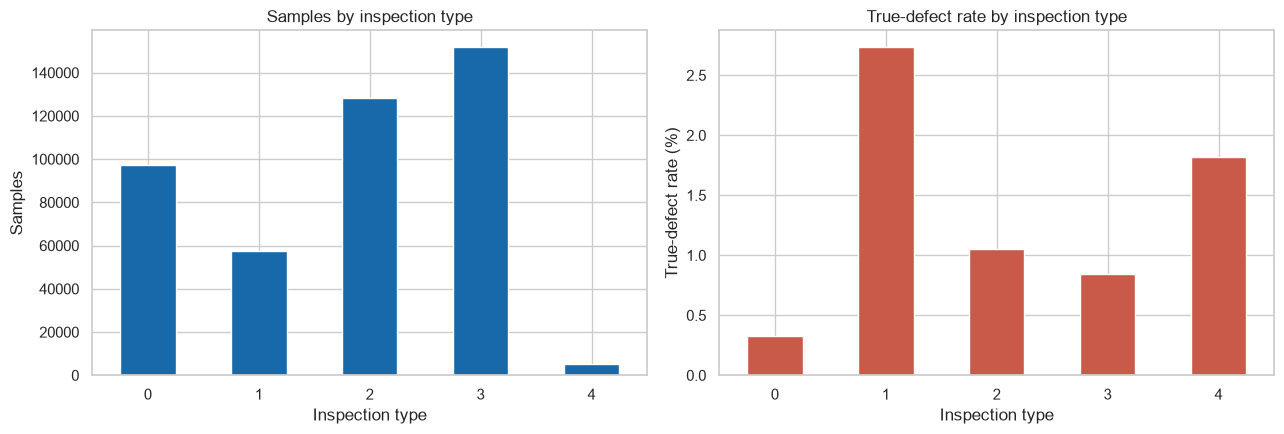

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

by_type["samples"].plot(kind="bar", ax=axes[0], color="#1769aa")
axes[0].set_title("Samples by inspection type")
axes[0].set_xlabel("Inspection type")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis="x", rotation=0)

by_type["defect_rate_pct"].plot(kind="bar", ax=axes[1], color="#c95a49")
axes[1].set_title("True-defect rate by inspection type")
axes[1].set_xlabel("Inspection type")
axes[1].set_ylabel("True-defect rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 5. `mapping.json`과 검사유형별 유효 피처

논문은 검사유형에 따라 `inspection_feat`의 물리적 의미와 사용 여부가 달라진다고 설명합니다. 따라서 전체 피처를 하나의 동일한 측정값처럼 해석하지 않고, 매핑의 완전성과 유형별 유효 피처 수를 먼저 검증합니다.

In [8]:
inspection_types = sorted(df[TYPE_COLUMN].unique().tolist())
mapping_keys = sorted(int(key) for key in mapping)
mapping_rows = []
for inspection_type in inspection_types:
    mapped_columns = mapping[str(inspection_type)]
    mapping_rows.append(
        {
            "inspection_type": inspection_type,
            "mapped_features": len(mapped_columns),
            "unique_mapped_features": len(set(mapped_columns)),
            "missing_from_dataset": len(set(mapped_columns) - set(INSPECTION_COLUMNS)),
            "unmapped_dataset_features": len(set(INSPECTION_COLUMNS) - set(mapped_columns)),
        }
    )
mapping_summary = pd.DataFrame(mapping_rows).set_index("inspection_type")

features_available_to_all_types = sorted(
    set.intersection(*(set(mapping[str(inspection_type)]) for inspection_type in inspection_types))
)

assert inspection_types == mapping_keys, "데이터와 mapping.json의 inspection_type이 다릅니다."
assert mapping_summary["missing_from_dataset"].sum() == 0, "매핑에 CSV에 없는 피처가 있습니다."
assert all(
    len(columns) == len(set(columns)) for columns in mapping.values()
), "mapping.json 내부에 중복 피처가 있습니다."

display(mapping_summary)
print("features available to all inspection types:", len(features_available_to_all_types))

,mapped_features,unique_mapped_features,missing_from_dataset,unmapped_dataset_features
inspection_type,,,,
0,44,44,0,26
1,52,52,0,18
2,65,65,0,5
3,65,65,0,5
4,21,21,0,49


features available to all inspection types: 17


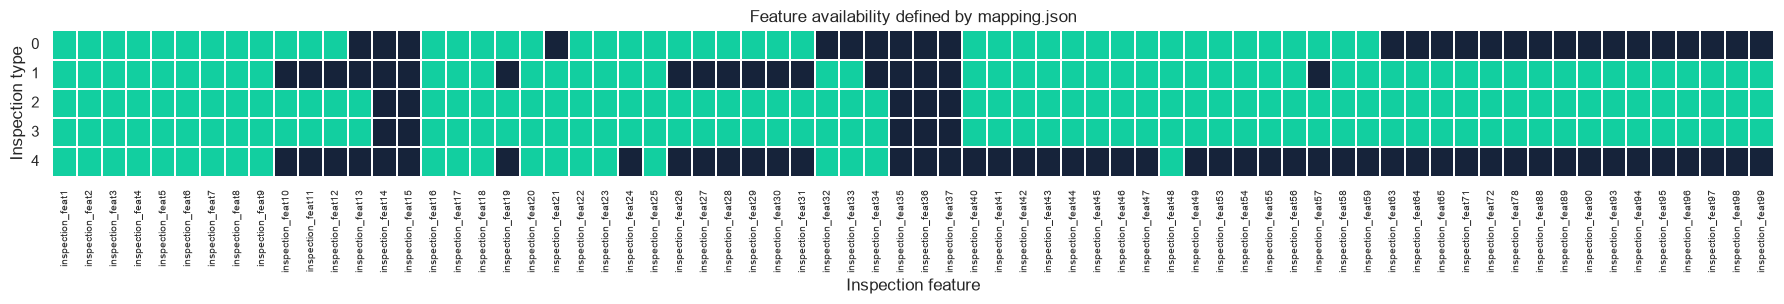

In [9]:
availability = pd.DataFrame(
    0,
    index=inspection_types,
    columns=INSPECTION_COLUMNS,
    dtype=int,
)
for inspection_type in inspection_types:
    availability.loc[inspection_type, mapping[str(inspection_type)]] = 1

plt.figure(figsize=(18, 3.2))
sns.heatmap(
    availability,
    cmap=sns.color_palette(["#16233a", "#12cfa0"]),
    cbar=False,
    linewidths=0.05,
)
plt.title("Feature availability defined by mapping.json")
plt.xlabel("Inspection feature")
plt.ylabel("Inspection type")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
type_feature_rows = []
for inspection_type in inspection_types:
    group = df.loc[df[TYPE_COLUMN] == inspection_type]
    valid_columns = mapping[str(inspection_type)]
    invalid_columns = sorted(set(INSPECTION_COLUMNS) - set(valid_columns))
    valid_unique_counts = group[valid_columns].nunique(dropna=False)
    invalid_values = group[invalid_columns].to_numpy()
    type_feature_rows.append(
        {
            "inspection_type": inspection_type,
            "valid_features": len(valid_columns),
            "valid_constant_features": int((valid_unique_counts <= 1).sum()),
            "invalid_features": len(invalid_columns),
            "invalid_cells": int(invalid_values.size),
            "invalid_zero_rate_pct": float((invalid_values == 0).mean() * 100),
        }
    )
type_feature_summary = pd.DataFrame(type_feature_rows).set_index("inspection_type")
display(type_feature_summary)

,valid_features,valid_constant_features,invalid_features,invalid_cells,invalid_zero_rate_pct
inspection_type,,,,,
0,44,7,26,2523378,61.5385
1,52,28,18,1038114,44.4452
2,65,45,5,640870,0.0000
3,65,46,5,759655,0.0000
4,21,8,49,266707,72.4713


`mapping.json`에서 제외된 피처의 값이 항상 0인지 위 표로 검증합니다. 0이 아닌 채움값이 하나라도 존재하면 값 자체로 유효 여부를 추론할 수 없으므로, 후속 전처리에서는 매핑을 명시적으로 적용해야 합니다. 또한 유효 피처 중 상수열은 검사유형별로 제거 후보가 됩니다.

## 6. 메타 피처와 검사 피처의 기초 통계

논문은 `meta_feat`를 범주형 변수로 설명하고, `inspection_feat`는 익명화를 위해 0~1로 스케일했다고 명시합니다. 실제 자료형과 값 범위를 집계로 확인합니다.

In [11]:
meta_summary = pd.DataFrame(
    {
        "dtype": df[META_COLUMNS].dtypes.astype(str),
        "unique_count": df[META_COLUMNS].nunique(dropna=False),
        "missing_count": df[META_COLUMNS].isna().sum(),
    }
)
display(meta_summary)

inspection_min = df[INSPECTION_COLUMNS].min()
inspection_max = df[INSPECTION_COLUMNS].max()
inspection_unique = df[INSPECTION_COLUMNS].nunique(dropna=False)
inspection_profile = pd.DataFrame(
    {
        "min": inspection_min,
        "max": inspection_max,
        "unique_count": inspection_unique,
        "missing_count": df[INSPECTION_COLUMNS].isna().sum(),
    }
)
outside_unit_interval = int(
    ((df[INSPECTION_COLUMNS] < 0) | (df[INSPECTION_COLUMNS] > 1)).to_numpy().sum()
)
display(inspection_profile.describe().T)
print("inspection values outside [0, 1]:", outside_unit_interval)

,dtype,unique_count,missing_count
meta_feat1,int64,75,0
meta_feat2,int64,5,0
meta_feat3,int64,2,0
meta_feat4,int64,49,0


,count,mean,std,min,25%,50%,75%,max
min,70.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,70.0000,0.9143,0.2820,0.0000,1.0000,1.0000,1.0000,1.0000
unique_count,70.0000,302.1714,426.5007,1.0000,88.2500,181.0000,364.5000,"2,846.0000"
missing_count,70.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


inspection values outside [0, 1]: 0


## 7. 시간 범위와 timestamp 그룹 구조

논문에 따르면 같은 PCB의 여러 검사 지점은 동일 timestamp를 공유할 수 있습니다. 따라서 timestamp를 단순 피처로만 보지 않고 시간 순서와 그룹 경계로 사용해야 합니다.

In [12]:
parsed_timestamp = pd.to_datetime(df[TIME_COLUMN], errors="coerce", utc=True)
timestamp_parse_failures = int(parsed_timestamp.isna().sum())
timestamp_min = parsed_timestamp.min()
timestamp_max = parsed_timestamp.max()
timestamp_span_days = int((timestamp_max - timestamp_min).days)
dates = parsed_timestamp.dt.floor("D")
active_days = int(dates.nunique())
calendar_days_inclusive = int((dates.max() - dates.min()).days + 1)
inactive_calendar_days = calendar_days_inclusive - active_days

timestamp_groups = df.groupby(TIME_COLUMN, sort=False)
timestamp_group_sizes = timestamp_groups.size()
timestamp_type_counts = timestamp_groups[TYPE_COLUMN].nunique()
timestamp_class_counts = timestamp_groups[TARGET].nunique()

time_summary = pd.Series(
    {
        "timestamp_parse_failures": timestamp_parse_failures,
        "first_timestamp": timestamp_min,
        "last_timestamp": timestamp_max,
        "span_days": timestamp_span_days,
        "active_days": active_days,
        "inactive_calendar_days": inactive_calendar_days,
        "unique_timestamp_groups": timestamp_group_sizes.size,
        "groups_with_multiple_rows": int((timestamp_group_sizes > 1).sum()),
        "groups_with_multiple_inspection_types": int((timestamp_type_counts > 1).sum()),
        "groups_with_mixed_labels": int((timestamp_class_counts > 1).sum()),
    },
    name="value",
)
display(time_summary.to_frame())
display(timestamp_group_sizes.describe().rename("rows_per_timestamp").to_frame())

,value
timestamp_parse_failures,0
first_timestamp,1970-06-23 03:58:55+00:00
last_timestamp,1970-11-02 14:21:28+00:00
span_days,132
active_days,101
inactive_calendar_days,32
unique_timestamp_groups,39742
groups_with_multiple_rows,33902
groups_with_multiple_inspection_types,27322
groups_with_mixed_labels,715


,rows_per_timestamp
count,"39,742.0000"
mean,11.0783
std,16.1136
min,1.0000
25%,2.0000
50%,6.0000
75%,15.0000
max,557.0000


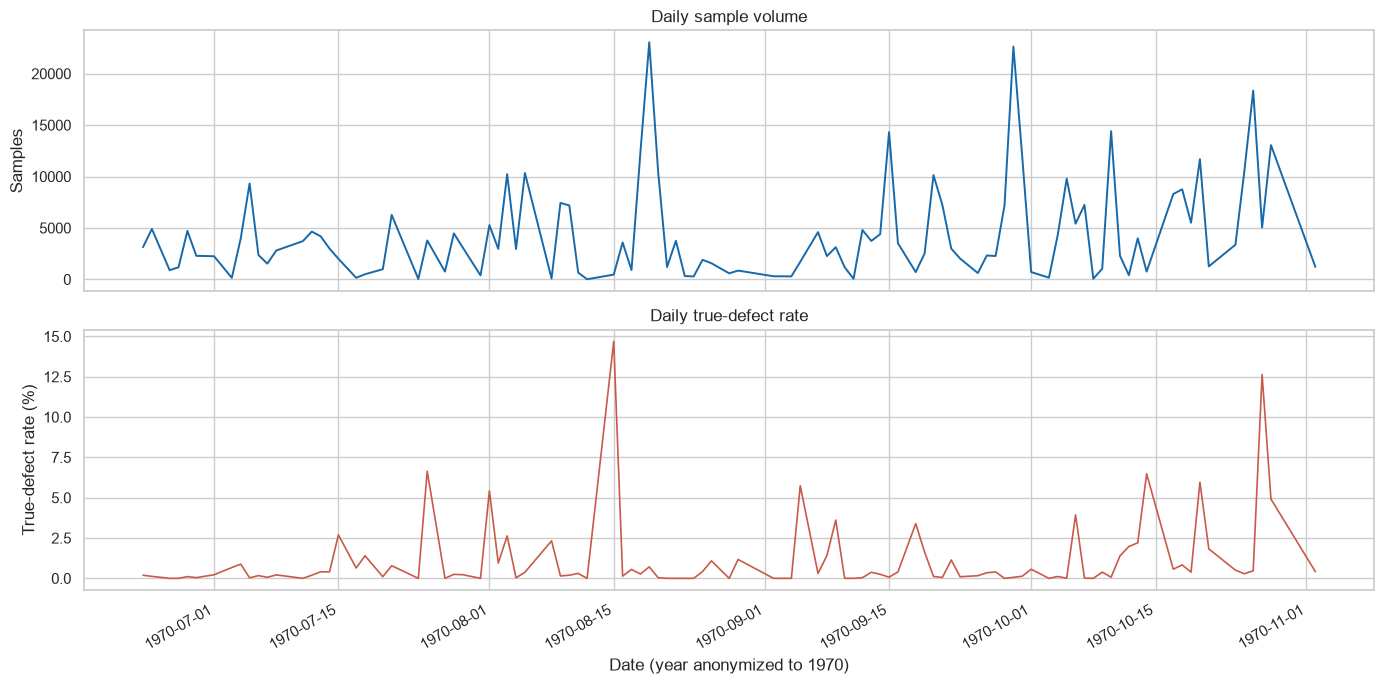

,value
minimum_daily_samples,12.0000
median_daily_samples,"2,993.0000"
maximum_daily_samples,"23,046.0000"
minimum_daily_defect_rate_pct,0.0000
maximum_daily_defect_rate_pct,14.6868


In [13]:
daily = (
    pd.DataFrame({"date": dates, TARGET: df[TARGET]})
    .groupby("date", observed=True)[TARGET]
    .agg(samples="size", true_defects="sum", defect_rate="mean")
    .sort_index()
)
daily["defect_rate_pct"] = daily["defect_rate"] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
daily["samples"].plot(ax=axes[0], color="#1769aa", linewidth=1.4)
axes[0].set_title("Daily sample volume")
axes[0].set_ylabel("Samples")

daily["defect_rate_pct"].plot(ax=axes[1], color="#c95a49", linewidth=1.2)
axes[1].set_title("Daily true-defect rate")
axes[1].set_ylabel("True-defect rate (%)")
axes[1].set_xlabel("Date (year anonymized to 1970)")

plt.tight_layout()
plt.show()

display(
    pd.Series(
        {
            "minimum_daily_samples": int(daily["samples"].min()),
            "median_daily_samples": float(daily["samples"].median()),
            "maximum_daily_samples": int(daily["samples"].max()),
            "minimum_daily_defect_rate_pct": float(daily["defect_rate_pct"].min()),
            "maximum_daily_defect_rate_pct": float(daily["defect_rate_pct"].max()),
        },
        name="value",
    ).to_frame()
)

## 8. 결론 및 다음 실험 제안

아래 결론은 위에서 계산된 집계를 사용해 자동 생성합니다. 후속 실험에서는 원본을 수정하지 않고, 검사유형별 매핑과 시간·그룹 경계를 명시적으로 적용해야 합니다.

In [14]:
invalid_zero_rule_holds = bool((type_feature_summary["invalid_zero_rate_pct"] == 100).all())

conclusion = f"""
### 핵심 결과

- 데이터는 **{len(df):,}행 × {len(OFFICIAL_COLUMNS)}개 공식 컬럼**이며, 별도의 행 식별자 1개가 있습니다.
- true defect는 **{int(class_counts.get(1, 0)):,}건 ({overall_defect_rate * 100:.2f}%)**으로 극심한 불균형입니다. 검사유형별 비율도 서로 달라 단순 Accuracy는 핵심 평가 지표로 부적절합니다.
- 결측 셀은 **{missing_cells:,}건**, 무한값은 **{infinite_cells:,}건**입니다. `record_id`를 제외한 완전 중복 초과 행은 **{duplicate_excess_rows:,}건 ({duplicate_excess_rows / len(df) * 100:.2f}%)**입니다.
- `mapping.json`은 데이터의 5개 검사유형과 일치하며, 모든 유형에 공통으로 유효한 검사 피처는 **{len(features_available_to_all_types)}개**입니다.
- 매핑에서 제외된 피처가 항상 0이라는 규칙은 **{'성립합니다' if invalid_zero_rule_holds else '성립하지 않습니다'}**. 따라서 피처 유효성은 값이 아니라 `mapping.json`으로 판정해야 합니다.
- timestamp는 **{timestamp_span_days}일** 범위에 걸쳐 있고 실제 관측일은 **{active_days}일**, 비관측일은 **{inactive_calendar_days}일**입니다. 고유 timestamp 그룹은 **{timestamp_group_sizes.size:,}개**입니다.

### 모델링 전 결정할 사항

1. 검사유형별 모델 또는 검사유형을 명시적으로 처리하는 전처리 전략을 사용합니다.
2. 같은 timestamp 그룹이 서로 다른 데이터 분할에 섞이지 않도록 하고, 무작위 분할보다 시간순 Train/Validation/Test 분할을 우선 검토합니다.
3. PR-AUC, true-defect recall, false-call reduction처럼 불균형과 운영 비용을 반영한 지표를 사용합니다.
4. 완전 중복행의 발생 원인과 제거 기준은 별도 실험에서 확인합니다.

### 후속 EDA 후보

- `002_temporal_drift`: 시간 구간별 피처·타깃·검사유형 분포 변화 정량화
- `003_feature_validity`: 검사유형별 상수열·저분산열·무효 피처 채움 패턴 분석
- `004_duplicate_groups`: 완전 중복과 timestamp 그룹의 발생 구조 및 분할 영향 분석
"""
display(Markdown(conclusion))


### 핵심 결과

- 데이터는 **440,274행 × 77개 공식 컬럼**이며, 별도의 행 식별자 1개가 있습니다.
- true defect는 **4,622건 (1.05%)**으로 극심한 불균형입니다. 검사유형별 비율도 서로 달라 단순 Accuracy는 핵심 평가 지표로 부적절합니다.
- 결측 셀은 **0건**, 무한값은 **0건**입니다. `record_id`를 제외한 완전 중복 초과 행은 **8,752건 (1.99%)**입니다.
- `mapping.json`은 데이터의 5개 검사유형과 일치하며, 모든 유형에 공통으로 유효한 검사 피처는 **17개**입니다.
- 매핑에서 제외된 피처가 항상 0이라는 규칙은 **성립하지 않습니다**. 따라서 피처 유효성은 값이 아니라 `mapping.json`으로 판정해야 합니다.
- timestamp는 **132일** 범위에 걸쳐 있고 실제 관측일은 **101일**, 비관측일은 **32일**입니다. 고유 timestamp 그룹은 **39,742개**입니다.

### 모델링 전 결정할 사항

1. 검사유형별 모델 또는 검사유형을 명시적으로 처리하는 전처리 전략을 사용합니다.
2. 같은 timestamp 그룹이 서로 다른 데이터 분할에 섞이지 않도록 하고, 무작위 분할보다 시간순 Train/Validation/Test 분할을 우선 검토합니다.
3. PR-AUC, true-defect recall, false-call reduction처럼 불균형과 운영 비용을 반영한 지표를 사용합니다.
4. 완전 중복행의 발생 원인과 제거 기준은 별도 실험에서 확인합니다.

### 후속 EDA 후보

- `002_temporal_drift`: 시간 구간별 피처·타깃·검사유형 분포 변화 정량화
- `003_feature_validity`: 검사유형별 상수열·저분산열·무효 피처 채움 패턴 분석
- `004_duplicate_groups`: 완전 중복과 timestamp 그룹의 발생 구조 및 분할 영향 분석
